## 1. Linear Regression: Persamaan Normal

Untuk melatih model **Linear Regression**, kita perlu mencari nilai parameter $\theta$ yang meminimalkan error (MSE). Salah satu cara paling langsung adalah menggunakan rumus matematika yang disebut **Normal Equation**.

### Persamaan Normal

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$

### Kelebihan

- Memberikan solusi matematis yang tepat **tanpa perlu proses iterasi**.
- Cocok untuk dataset kecil hingga menengah.

### Kekurangan

- Sangat lambat jika jumlah fitur ($n$) sangat banyak (misal 100.000 fitur), karena komputasi **invers matriks** menjadi sangat berat.


## 2. Gradient Descent (GD)

**Gradient Descent** adalah algoritma optimasi generik yang mampu menemukan solusi optimal dengan cara **mengubah parameter secara bertahap** untuk meminimalkan fungsi biaya.

### 2.1 Konsep Dasar

Analogi:  
Kamu berada di puncak gunung dalam kabut tebal. Kamu merasakan kemiringan tanah dan melangkah ke arah yang paling curam ke bawah hingga sampai ke lembah (**titik minimum**).

- **Learning Rate** ($\alpha$): Ukuran langkah yang diambil.  
  - Jika terlalu kecil → proses belajar sangat lambat  
  - Jika terlalu besar → bisa "melompati" lembah dan gagal menemukan titik minimum

Persamaan umum update parameter untuk Gradient Descent:

$$
\theta := \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}
$$

di mana $J(\theta)$ adalah **fungsi biaya** yang ingin diminimalkan.

### 2.2 Jenis-Jenis Gradient Descent

1. **Batch Gradient Descent**  
   - Menggunakan seluruh dataset untuk menghitung gradien di setiap langkah  
   - Akurat, tapi **sangat lambat** untuk dataset besar

2. **Stochastic Gradient Descent (SGD)**  
   - Mengambil **satu sampel acak** di setiap langkah  
   - Cepat dan bisa menangani dataset raksasa  
   - Jalur update sering "zigzag" → lebih **tidak stabil**

3. **Mini-batch Gradient Descent**  
   - Mengambil **sekelompok kecil sampel acak**  
   - Lebih stabil dari SGD dan lebih cepat dibandingkan Batch GD  
   - Umumnya digunakan di praktek Deep Learning

## 3. Polynomial Regression

Jika data **tidak berbentuk garis lurus (non-linear)**, kita bisa menggunakan model linear untuk menangani data non-linear dengan **menambahkan pangkat dari fitur**.

- **Teknik**:  
  Gunakan `PolynomialFeatures` untuk mengubah fitur $x$ menjadi $x^2$, $x^3$, dst., lalu latih model menggunakan **Linear Regression biasa**

- **Risiko**:  
  Semakin tinggi pangkatnya, semakin besar kemungkinan model mengalami **Overfitting** (terlalu mengikuti noise data)


## 4. Regularized Linear Models (Mencegah Overfitting)

Cara terbaik untuk mengurangi **overfitting** adalah dengan **membatasi model** melalui regularisasi. Semakin sedikit kebebasan yang dimiliki model, semakin sulit model tersebut melakukan overfitting.

### Ridge Regression

- Menambahkan **penalti pada fungsi biaya** sehingga bobot model tetap sekecil mungkin  
- Membantu mencegah bobot menjadi terlalu besar

### Lasso Regression

- Mirip Ridge, tetapi bisa **menghapus bobot fitur yang tidak penting menjadi nol**  
- Secara otomatis melakukan **seleksi fitur**

### Elastic Net

- Gabungan antara Ridge dan Lasso  
- Digunakan jika Lasso terlalu ekstrem dalam menghapus fitur

## 5. Logistic Regression

Meskipun namanya “Regression”, algoritma ini sebenarnya digunakan untuk **Klasifikasi**.

### Fungsi Sigmoid

- Menghitung **probabilitas** (antara 0 dan 1) menggunakan fungsi logistik  
- Jika probabilitas > 0.5 → diklasifikasikan sebagai kelas positif

### Softmax Regression

- Pengembangan dari Logistic Regression yang bisa menangani **banyak kelas sekaligus (Multiclass)**  
- Tidak terbatas hanya pada kasus biner (Ya/Tidak)

## **Contoh Kode: Normal Equation vs Scikit-Learn**

Bias (Intercept): [3.98444067]
Weight (Coefficient): [[2.94605184]]


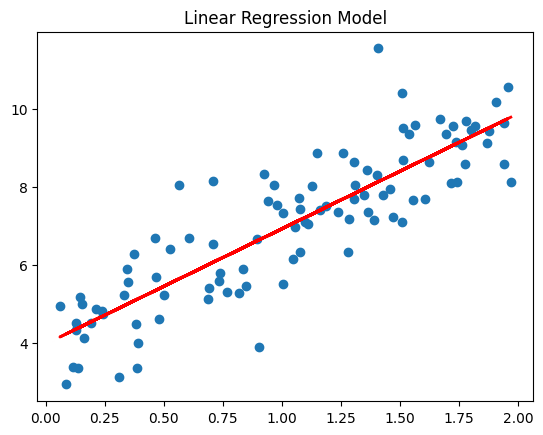

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Menghasilkan data acak (Linear-ish)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 2. Menggunakan Linear Regression (Scikit-Learn secara otomatis memilih cara terbaik)
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# 3. Menampilkan Parameter (Intercept dan Koefisien)
print(f"Bias (Intercept): {lin_reg.intercept_}")
print(f"Weight (Coefficient): {lin_reg.coef_}")

# 4. Visualisasi
plt.scatter(X, y)
plt.plot(X, lin_reg.predict(X), color='red', linewidth=2)
plt.title("Linear Regression Model")
plt.show()

## 6. Learning Curves

Untuk mengetahui apakah sebuah model mengalami **Overfitting** atau **Underfitting**, kita bisa melihat **Learning Curves**.

### Underfitting

- Kedua kurva (**training** dan **validation**) berada **berdekatan**, tetapi memiliki **error yang tinggi**  
- Menambah data pelatihan **tidak banyak membantu**  
- Solusi: Gunakan **model yang lebih kompleks**

### Overfitting

- Terdapat **celah lebar** antara kurva **training** (error rendah) dan kurva **validation** (error tinggi)  
- Solusi:  
  - Menambah data pelatihan  
  - Menggunakan **teknik regularisasi**  

## 7. The Bias/Variance Trade-off

Kesalahan generalisasi model terdiri dari **tiga bagian utama**:

### Bias

- Kesalahan karena **asumsi yang salah**  
- Contoh: Menganggap data linear padahal non-linear  
- Akibat: **Underfitting**

### Variance

- Kesalahan karena **sensitivitas berlebih model terhadap variasi kecil pada data training**  
- Akibat: **Overfitting**

### Irreducible Error

- Kesalahan karena **noise pada data**  
- Satu-satunya cara menguranginya adalah dengan **membersihkan data**

# Chapter 5: Support Vector Machines (SVM)

## 1. Klasifikasi Linear SVM

Bayangkan ada dua kelompok data yang bisa dipisahkan dengan **garis lurus**. SVM mencoba mencari **garis pemisah terbaik** yang tidak hanya memisahkan kedua kelompok, tetapi juga memberikan **jarak (margin) sejauh mungkin** dari titik data terdekat.

### Large Margin Classification

- SVM menganggap garis terbaik adalah yang memiliki **"jalan raya" terlebar** di antara dua kelas

### Support Vectors

- Titik-titik data yang berada tepat di pinggir margin  
- Jika titik ini dihapus → batas pemisah akan berubah

### Hard Margin Classification

- Memaksa semua data berada di luar margin  
- Sangat **sensitif terhadap outlier**

### Soft Margin Classification

- Membolehkan beberapa pelanggaran (titik masuk ke margin) agar model lebih fleksibel dan **generalisasinya lebih baik**  
- Dikontrol oleh parameter **C**:  
  - **C kecil** → Margin lebih lebar, tapi banyak pelanggaran (**High Bias**)  
  - **C besar** → Margin lebih sempit, sedikit pelanggaran (**High Variance / Overfitting**)


## 2. Klasifikasi SVM Non-Linear

Banyak dataset **tidak bisa dipisahkan dengan garis lurus**. SVM menangani ini dengan dua cara:

### A. Menambah Fitur Polinomial

- Menambahkan fitur baru seperti $x^2$  
- Data yang tadinya menyatu di 1D bisa **terpisah di 2D atau 3D**

### B. Kernel Trick

- “Sihir” matematika SVM  
- Memberikan hasil **sama seperti menambah fitur polinomial tingkat tinggi** tanpa menghitung fiturnya  
- Lebih cepat secara komputasi

#### Jenis Kernel Populer

- **Polynomial Kernel** → Untuk pola data melengkung  
- **RBF Kernel (Gaussian Radial Basis Function)** → Paling populer, sangat efektif untuk pola data yang **kompleks dan bertumpuk**

## 3. SVM Regression

Berbeda dengan klasifikasi, yang mencoba memuat **sesedikit mungkin data di dalam margin**, **SVM Regression** mencoba memuat **sebanyak mungkin data di dalam margin** sambil tetap menjaga batas luar seminimal mungkin.

- **Parameter $\epsilon$ (epsilon)**: Mengontrol **lebar margin**  
  - Semakin besar $\epsilon$ → semakin lebar "jalan" yang menampung data


## 4. Pentingnya Feature Scaling
Sangat Penting! SVM sangat sensitif terhadap skala fitur. Jika satu fitur punya rentang 0-1 dan fitur lain 0-1.000.000, margin akan terlihat sangat gepeng dan model akan bekerja buruk. Selalu gunakan StandardScaler sebelum melatih SVM.

## **Contoh Kode: Linear SVM dengan StandardScaler**

In [2]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# 1. Load data Iris (Hanya dua fitur untuk contoh: Petal length & width)
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64) # Iris-Virginica

# 2. Membuat Pipeline: Scale -> Linear SVM
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
])

# 3. Latih Model
svm_clf.fit(X, y)

# 4. Prediksi
print(f"Prediksi untuk data [5.5, 1.7]: {svm_clf.predict([[5.5, 1.7]])}")

Prediksi untuk data [5.5, 1.7]: [1.]


## 6. Kernel Trick dan Karakteristiknya

Jika data **tidak bisa dipisahkan secara linear**, kita menggunakan **Kernel**.  
Kernel memungkinkan kita memetakan data ke **dimensi yang lebih tinggi** tanpa beban komputasi yang berat.

- **Linear Kernel**: Digunakan jika data sudah terlihat bisa dipisahkan dengan garis lurus (cepat dan simpel)  
- **Polynomial Kernel**: Cocok untuk data yang memiliki **pola melengkung atau lingkaran**  
- **Gaussian RBF Kernel**: Kernel yang paling sering digunakan  
  - Sangat efektif untuk menangani data yang **sangat kompleks dan tidak beraturan**


## 7. Analogi Parameter Gamma ($\gamma$)

Khusus untuk **kernel RBF**, ada parameter penting bernama **Gamma ($\gamma$)**:

- **Gamma Kecil**: Membuat kurva keputusan lebih **halus dan lebar** (lebih general)  
- **Gamma Besar**: Membuat kurva sangat **sensitif pada setiap titik data**  
  - Berisiko **overfitting**, karena kurva akan sangat “liuk-liuk” mengikuti data

# Chapter 6: Decision Trees

## 1. Pelatihan dan Visualisasi Decision Tree

Decision Tree bekerja dengan cara **membagi dataset menjadi subset-subset** berdasarkan fitur yang paling signifikan. Algoritma ini membuat keputusan seperti **diagram alir (flowchart)**.

- **Root Node**: Titik awal pohon (fitur pertama yang diuji)  
- **Leaf Node**: Titik akhir yang memberikan **prediksi kelas** (tidak ada cabang lagi)  
- **Interpretability**: Decision Tree sering disebut **White Box Model** karena kita bisa melihat dengan jelas alasan model mengambil keputusan tertentu



## 2. Membuat Prediksi (Algoritma CART)

Scikit-Learn menggunakan algoritma **CART (Classification and Regression Tree)** untuk melatih pohon:

- Algoritma membagi data menjadi dua (**biner**) di setiap langkah  
- Pencarian dilakukan untuk menemukan **fitur dan threshold** yang menghasilkan subset paling "murni" (paling seragam)


## 3. Gini Impurity vs Entropy

Bagaimana pohon memutuskan **fitur mana yang harus digunakan** untuk membagi data? Ada dua metrik utama:

- **Gini Impurity**  
  - Mengukur seberapa sering elemen yang dipilih secara acak akan **salah diklasifikasikan**  
  - Skor 0 → node "murni" (semua data dalam satu kelas)

- **Entropy**  
  - Berasal dari teori informasi  
  - Node memiliki **entropy 0** jika semua data di dalamnya milik kelas yang sama

> **Catatan**: Secara praktis, keduanya memberikan hasil yang mirip, tetapi **Gini sedikit lebih cepat dihitung**

## 4. Regularisasi Hyperparameter

Decision Tree cenderung **overfitting** (menghafal data training hingga detail/noise). Untuk mencegahnya, kita perlu **membatasi kebebasan pohon** dengan beberapa hyperparameter:

- **max_depth**: Membatasi kedalaman pohon  
- **min_samples_split**: Jumlah minimum sampel yang harus dimiliki sebuah node sebelum bisa dibagi lagi  
- **min_samples_leaf**: Jumlah minimum sampel yang harus dimiliki sebuah leaf node  
- **max_leaf_nodes**: Batas maksimum jumlah leaf node


## 5. Decision Tree untuk Regresi

Selain klasifikasi, Decision Tree juga bisa memprediksi **nilai kontinu**:

- Setiap **leaf node** memberikan **nilai rata-rata** dari sampel yang jatuh ke sana  
- Tujuannya adalah meminimalkan **MSE (Mean Squared Error)** di setiap bagian


## 6. Instabilitas

Meskipun hebat, Decision Tree punya kelemahan utama:

- **Sensitif terhadap Rotasi**: Jika data diputar sedikit saja, batas keputusan bisa berubah drastis  
- **Varians Tinggi**: Perubahan kecil pada data training bisa menghasilkan pohon yang sangat berbeda  
  - Masalah ini nantinya diatasi oleh **Random Forests**

## **Contoh Kode: Melatih dan Memvisualisasikan Decision Tree**

Probabilitas kelas: [[0.         0.90740741 0.09259259]]
Prediksi kelas: [1]


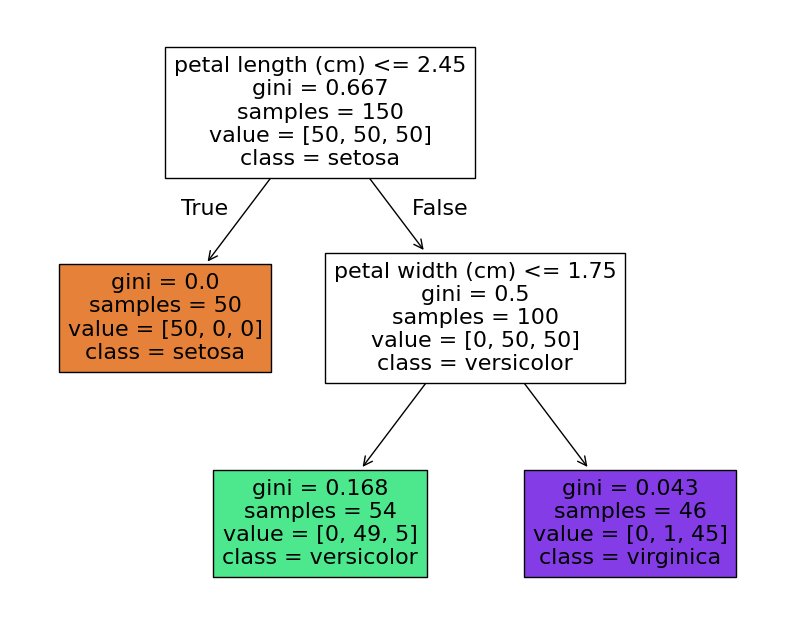

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# 1. Load data
iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

# 2. Latih Decision Tree (Klasifikasi)
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# 3. Prediksi probabilitas dan kelas
print(f"Probabilitas kelas: {tree_clf.predict_proba([[5, 1.5]])}")
print(f"Prediksi kelas: {tree_clf.predict([[5, 1.5]])}")

# Catatan: Kamu bisa menggunakan 'plot_tree' dari sklearn.tree untuk visualisasi langsung di notebook
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names[2:], class_names=iris.target_names)
plt.show()

## 7. Analisis Batas Keputusan (Decision Boundaries)

Decision Tree membagi ruang data dengan garis-garis yang **selalu tegak lurus** (horizontal atau vertikal). Ini disebut **axis-parallel splits**.

- **Kelebihan**: Sangat mudah dipahami  
  - Kita bisa melihat pada panjang/lebar berapa bunga dikategorikan sebagai Versicolor atau Virginica  
- **Kekurangan**: Jika data memiliki **pola miring (diagonal)**  
  - Decision Tree akan membuat "anak tangga" yang tidak perlu  
  - Akibatnya model menjadi kurang efisien


## 8. Masalah Instabilitas

Decision Tree sangat **sensitif terhadap perubahan kecil** dalam data pelatihan:

- **Varians Tinggi**:  
  - Menghapus satu sampel saja (misal satu bunga) → bisa menghasilkan struktur pohon yang **sama sekali berbeda**  
- **Sensitivitas Rotasi**:  
  - Memutar dataset (misal dengan PCA) → batas keputusan yang tadinya sederhana bisa menjadi sangat kompleks